# Wimbledon Match Statistics From 2000 to 2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

### Importing the dataset (average number of aces per year)

In [150]:
avg_aces_df = pd.read_csv('../SQL/First_queries/avg_aces_over_years.csv')
# avg_aces_df.head()


In [151]:
avg_aces_df['avg_aces'] = avg_aces_df['avg_aces'].round(1)
avg_aces_df.head()


,year,avg_aces
0,2000,25.0
1,2001,39.3
2,2002,13.0
3,2003,24.0
4,2004,18.0


In [159]:
avg_aces_df

,year,avg_aces
0,2000,25.0
1,2001,39.3
2,2002,13.0
3,2003,24.0
4,2004,18.0
5,2005,24.0
6,2006,13.7
7,2007,20.0
8,2008,22.7
9,2009,48.3


In [152]:
# Average number of aces across all years
avg_aces = avg_aces_df['avg_aces'].mean()
print(round(avg_aces))

24


### Plotting the average number of aces per year

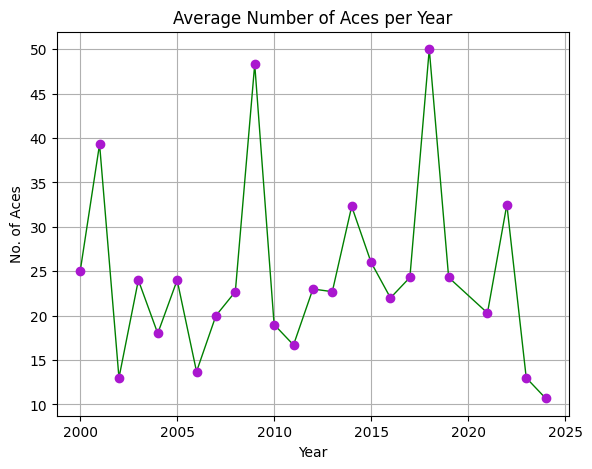

In [158]:
ace_fig = plt.figure()
ace_ax = ace_fig.add_axes([0.1, 0.5, 0.8, 0.8])

ace_ax.plot(
    avg_aces_df['year'], avg_aces_df['avg_aces'],
    color = 'green',
    lw=1,
    marker = 'o',
    markerfacecolor = '#aa17cf',
    markeredgecolor = '#aa17cf'
)

ace_ax.set_xlabel('Year')
ace_ax.set_ylabel('No. of Aces')
ace_ax.set_title('Average Number of Aces per Year')

ace_ax.grid()

In [157]:
ace_fig.savefig('../results/avg_ace_per_year_plot.png', bbox_inches='tight')

---
## Average number of double faults over the years
Again looking at semi finals and finals wimbledon matches

In [160]:
dbf_df = pd.read_csv('../SQL/First_queries/avg_double_faults_over_years.csv')
dbf_df.head()

,year,avg_double_faults
0,2000,15.0
1,2001,16.0
2,2002,7.0
3,2003,4.0
4,2004,9.0


In [161]:
avg_dbf = dbf_df['avg_double_faults'].mean()
print(avg_dbf)

6.715283333333333


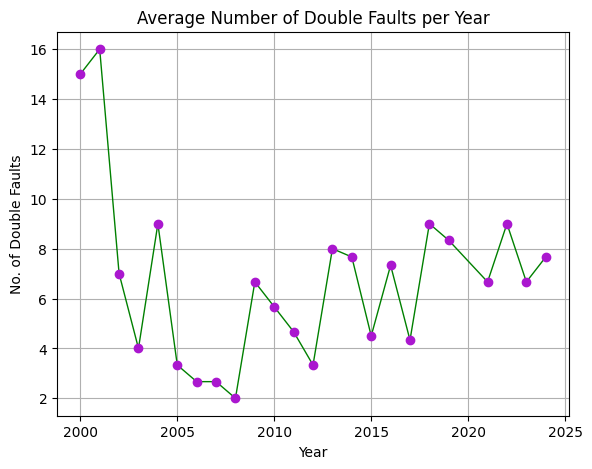

In [162]:
dbf_fig = plt.figure()
dbf_ax = dbf_fig.add_axes([0.1, 0.5, 0.8, 0.8])

dbf_ax.plot(
    dbf_df['year'], dbf_df['avg_double_faults'],
    color = 'green',
    lw=1,
    marker = 'o',
    markerfacecolor = '#aa17cf',
    markeredgecolor = '#aa17cf'
)

dbf_ax.set_xlabel('Year')
dbf_ax.set_ylabel('No. of Double Faults')
dbf_ax.set_title('Average Number of Double Faults per Year')

dbf_ax.grid()

In [163]:
dbf_fig.savefig('../results/avg_db_faults_per_year_plot.png', bbox_inches='tight')


## Average first serves in %

In [164]:
fsi_df = pd.read_csv('../SQL/First_queries/avg_first_serves_in_over_years.csv')
fsi_df.head()

,year,avg_first_serve_in
0,2000,0.609
1,2001,0.614
2,2002,0.564
3,2003,0.587
4,2004,0.592


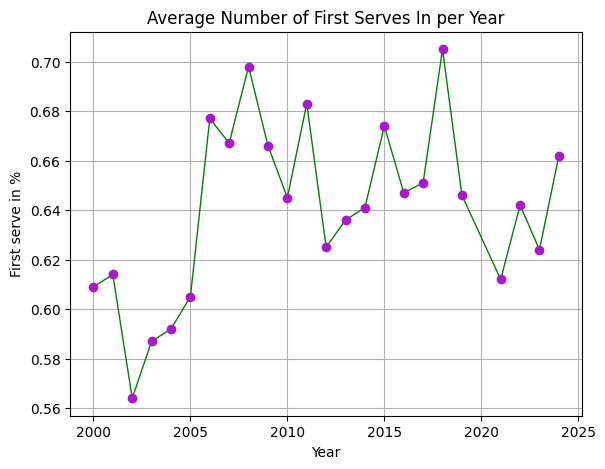

In [165]:
# Plotting average first serves in over the years 2000 - 2024

fsi_fig = plt.figure()
fsi_ax = fsi_fig.add_axes([0.1, 0.5, 0.8, 0.8])

fsi_ax.plot(
    fsi_df['year'], fsi_df['avg_first_serve_in'],
    color = 'green',
    lw=1,
    marker = 'o',
    markerfacecolor = '#aa17cf',
    markeredgecolor = '#aa17cf'
)

fsi_ax.set_xlabel('Year')
fsi_ax.set_ylabel('First serve in %')
fsi_ax.set_title('Average Number of First Serves In per Year')
fsi_ax.grid()

In [166]:
fsi_fig.savefig('../results/first_serves_in_over_years.png', bbox_inches='tight')


## Average Match Duration

In [3]:
match_len_df = pd.read_csv('../SQL/First_queries/avg_match_length_per_round_over_years.csv')
match_len_df.head()

,year,avg_match_length,round
0,2000,178,F
1,2000,149,SF
2,2001,182,F
3,2001,181,SF
4,2002,116,F


In [4]:
match_len_df

,year,avg_match_length,round
0,2000,178,F
1,2000,149,SF
2,2001,182,F
3,2001,181,SF
4,2002,116,F
5,2002,169,SF
6,2003,116,F
7,2003,110,SF
8,2004,151,F
9,2004,146,SF


In [5]:
# Average length of finals and semi's this century
match_len_df.groupby('round')['avg_match_length'].mean()

round
F     183.208333
SF    160.375000
Name: avg_match_length, dtype: float64

In [41]:
# Average match length in each decade - semis and finals

dec_df = match_len_df.copy()
dec_df['decade_col'] = dec_df['year'] // 10 * 10

dec_df[['avg_match_length', 'round', 'decade_col']].groupby(['round', 'decade_col']).mean()


avg_match_length
round decade_col                  
F     2000                  179.10
      2010                  179.10
      2020                  203.75
SF    2000                  139.20
      2010                  183.00
      2020                  156.75

In [171]:
# Showing the years with the longest final and the longest (avg semis)

longest_matches = match_len_df.loc[match_len_df.groupby('round')['avg_match_length'].idxmax()]
longest_matches


,year,avg_match_length,round
38,2019,297,F
37,2018,356,SF


In [173]:
# Splitting up finals and semi-finals

finals = match_len_df[match_len_df['round'] == 'F']
semis = match_len_df[match_len_df['round'] == 'SF']

finals.head()


,year,avg_match_length,round
0,2000,178,F
2,2001,182,F
4,2002,116,F
6,2003,116,F
8,2004,151,F


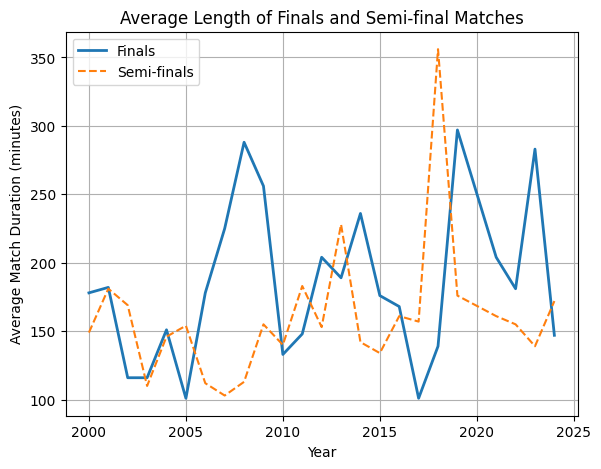

In [174]:
# Line graph of the average match lengths over the years, finals and semis

match_len_fig = plt.figure()

match_len_ax = match_len_fig.add_axes([0.1, 0.5, 0.8, 0.8])

match_len_ax.plot(finals['year'], finals['avg_match_length'], label = 'Finals', lw = '2')
match_len_ax.plot(semis['year'], semis['avg_match_length'], label = 'Semi-finals', linestyle = '--')


match_len_ax.set_xlabel('Year')
match_len_ax.set_ylabel('Average Match Duration (minutes)')
match_len_ax.set_title('Average Length of Finals and Semi-final Matches')
match_len_ax.legend(loc = 'upper left')
match_len_ax.grid()


In [175]:
match_len_fig.savefig('../results/match_length_per_year_plot.png', bbox_inches='tight')


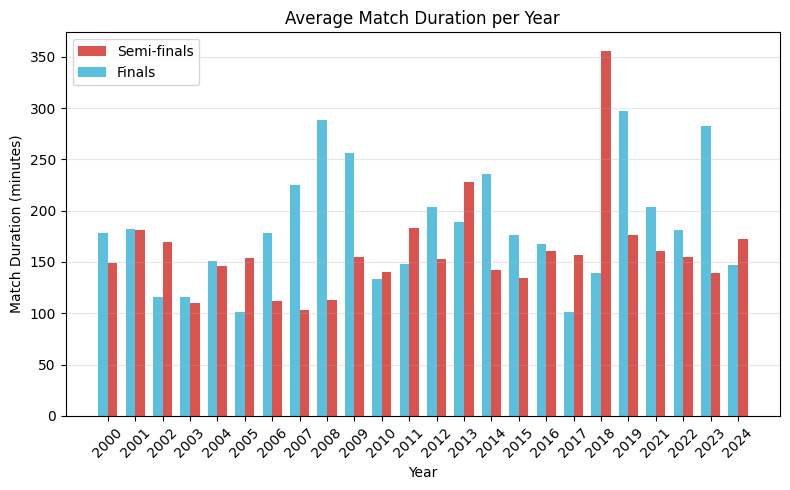

In [176]:
# Grouped Bar Graph of Match duration - Finals vs Semi-finals

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(finals['year']))
width = 0.35

ax.bar(
    x + width/2, semis['avg_match_length'],
    width=width,
    label='Semi-finals',
    color='#d9534f'
)

ax.bar(
    x - width/2, finals['avg_match_length'],
    width=width,
    label='Finals',
    color='#5bc0de'
)

ax.set_xticks(x)
ax.set_xticklabels(finals['year'], rotation=45)

ax.legend(loc = 'upper left')

ax.set_title('Average Match Duration per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Match Duration (minutes)')
ax.grid(axis = 'y', alpha = 0.3)
plt.tight_layout()
plt.show()


In [177]:
fig.savefig('../results/match_length_grouped_barplot_plot.png', bbox_inches='tight')


In [103]:
match_len_df[(match_len_df['year'] == 2008) & (match_len_df['round'] == 'F')]

,year,avg_match_length,round
16,2008,288,F


## Total points played

In [178]:
total_points_df = pd.read_csv('../SQL/First_queries/total_points_played_per_round_over_years.csv')
total_points_df.head()

,year,total_points_played,round
0,2000,299.0,F
1,2000,245.0,SF
2,2001,303.0,F
3,2001,309.5,SF
4,2002,168.0,F


In [179]:
# Splitting up matches by rounds

finals_points = total_points_df[total_points_df['round'] == 'F']
semis_points = total_points_df[total_points_df['round'] == 'SF']
finals_points.head()

,year,total_points_played,round
0,2000,299.0,F
2,2001,303.0,F
4,2002,168.0,F
6,2003,195.0,F
8,2004,287.0,F


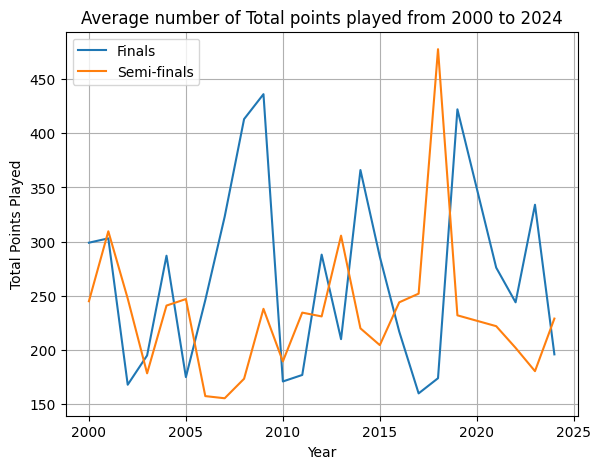

In [180]:
# Line graph for average total points played over 25 years
tot_points_fig = plt.figure()
tot_points_ax = tot_points_fig.add_axes([0.1, 0.5, 0.8, 0.8])

tot_points_ax.plot(finals_points['year'], finals_points['total_points_played'], label = 'Finals')
tot_points_ax.plot(semis_points['year'], semis_points['total_points_played'], label = 'Semi-finals')

tot_points_ax.set_xlabel('Year')
tot_points_ax.set_ylabel('Total Points Played')
tot_points_ax.set_title('Average number of Total points played from 2000 to 2024')
tot_points_ax.legend(loc = 'upper left')
tot_points_ax.grid()


In [181]:
tot_points_fig.savefig('../results/total_points_per_year.png', bbox_inches='tight')


## Scatter plot of match duration and first serve in %

In [182]:
merged_df = pd.merge(
    fsi_df[['year', 'avg_first_serve_in']],
    match_len_df[['year', 'avg_match_length', 'round']],
    on='year'
)
merged_df

,year,avg_first_serve_in,avg_match_length,round
0,2000,0.609,178,F
1,2000,0.609,149,SF
2,2001,0.614,182,F
3,2001,0.614,181,SF
4,2002,0.564,116,F
5,2002,0.564,169,SF
6,2003,0.587,116,F
7,2003,0.587,110,SF
8,2004,0.592,151,F
9,2004,0.592,146,SF


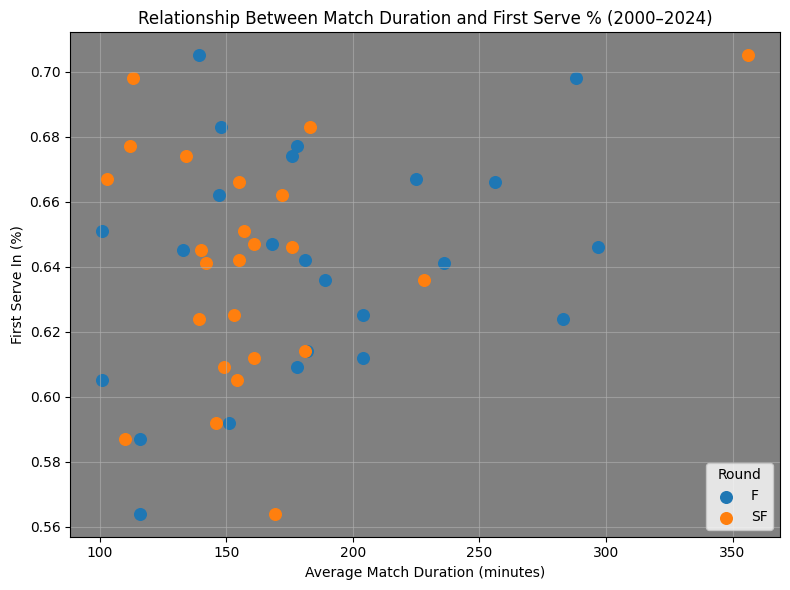

In [185]:
fig, ax = plt.subplots(figsize=(8, 6))

# Color by round
colors = {'F': '#1f77b4', 'SF': '#ff7f0e'}

for rnd, group in merged_df.groupby('round'):
    ax.scatter(
        group['avg_match_length'],
        group['avg_first_serve_in'],
        label = rnd,
        color = colors[rnd],
        s = 70,
    )
ax.set_xlabel('Average Match Duration (minutes)')
ax.set_ylabel('First Serve In (%)')
ax.set_title('Relationship Between Match Duration and First Serve % (2000–2024)')
# ax.set_facecolor("grey")
ax.legend(title='Round')
ax.grid(alpha=0.6)

plt.tight_layout()
plt.show()


In [186]:
fig.savefig('../results/scatter_plot2.png', bbox_inches='tight')
